# Robustness checks for SAX clustering

This notebook tests whether the final clustering is sensitive to SAX tuning choices, calendar subperiods, and term subsampling. Each section writes reproducible tables and figures to `06_robustness/`.


## 0. Setup and data alignment

Load the retained panel, final distance matrix, and final cluster assignments; standardize the one unnamed term created by CSV export; and verify that every input uses the same term universe.


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist, squareform
from scipy.stats import norm
from sklearn.metrics import adjusted_rand_score, silhouette_score

warnings.filterwarnings("ignore")

DATA_DIR = Path("C:/Python/CSUREMM/output")
OUTPUT_DIR = Path("C:/Python/CSUREMM/output/06_robustness")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PATH = DATA_DIR / "01_preprocessing/panel_normalized.csv"
RAW_PANEL_PATH = DATA_DIR / "01_preprocessing/panel_raw_retained.csv"
DISTANCE_PATH = DATA_DIR / "03_distance/sax_mindist_matrix_tiebroken_squared.csv"
LABELS_PATH = DATA_DIR / "04_clustering/final_cluster_assignments.csv"

RANDOM_STATE = 42
FINAL_K = 10

LINKAGE_METHOD = "ward"

# SAX parameter-robustness specification. Here, w is the SAX word length
# (the number of PAA segments) and a is the alphabet size.
BASE_W = 96
BASE_A = 9
W_GRID = [48, 64, 96, 128]
A_GRID = [5, 7, 9, 11]
MINDIST_CHUNK_SIZE = 256
SAX_BOOTSTRAP_ITERATIONS = 20
SAX_SUBSAMPLE_FRACTION = 0.80
SAX_LINKAGE_METHOD = "ward"
CLIP_BOUNDS = (-5.0, 5.0)

CONSENSUS_SUBSAMPLES = 1000
CONSENSUS_FRACTION = 0.80


def load_panel(path: Path) -> pd.DataFrame:
    panel = pd.read_csv(path, index_col=0)
    panel.index = pd.to_datetime(panel.index, errors="raise")
    panel = panel.sort_index()
    # The source CSV contains one blank term exported as "Unnamed: 10".
    panel = panel.rename(columns={"Unnamed: 10": "__unnamed_term__"})
    panel.columns = panel.columns.astype(str)
    return panel.apply(pd.to_numeric, errors="coerce")


def load_distance(path: Path) -> pd.DataFrame:
    distance = pd.read_csv(path, index_col=0)
    distance.index = distance.index.fillna("__unnamed_term__").astype(str)
    distance.columns = pd.Index(distance.columns).astype(str)
    distance.columns = distance.columns.where(
        ~distance.columns.str.match(r"^Unnamed: \d+$"),
        "__unnamed_term__",
    )
    return distance.apply(pd.to_numeric, errors="raise")


def load_labels(path: Path) -> pd.Series:
    labels = pd.read_csv(path)
    required = {"term", "cluster"}
    if not required.issubset(labels.columns):
        raise ValueError(f"{path.name} must contain columns: {sorted(required)}")
    labels["term"] = labels["term"].fillna("__unnamed_term__").astype(str)
    return labels.set_index("term")["cluster"].astype(int).rename("cluster")


panel_norm = load_panel(PANEL_PATH)
panel_raw = load_panel(RAW_PANEL_PATH)
mindist_tiebroken = load_distance(DISTANCE_PATH)
labels_final = load_labels(LABELS_PATH)

terms = mindist_tiebroken.index
if mindist_tiebroken.shape[0] != mindist_tiebroken.shape[1]:
    raise ValueError("The SAX distance matrix must be square.")
if not mindist_tiebroken.index.equals(mindist_tiebroken.columns):
    raise ValueError("Distance-matrix rows and columns must match in the same order.")
if not np.allclose(mindist_tiebroken, mindist_tiebroken.T, atol=1e-10):
    raise ValueError("The SAX distance matrix must be symmetric.")
if not np.allclose(np.diag(mindist_tiebroken), 0.0, atol=1e-10):
    raise ValueError("The SAX distance matrix must have a zero diagonal.")

for name, obj_terms in {
    "normalized panel": pd.Index(panel_norm.columns),
    "raw panel": pd.Index(panel_raw.columns),
    "final labels": pd.Index(labels_final.index),
}.items():
    missing = terms.difference(obj_terms)
    extra = obj_terms.difference(terms)
    if len(missing) or len(extra):
        raise ValueError(
            f"Term mismatch for {name}: {len(missing)} missing and {len(extra)} extra."
        )

panel_norm = panel_norm.loc[:, terms]
panel_raw = panel_raw.loc[:, terms]
labels_final = labels_final.reindex(terms)

if labels_final.nunique() != FINAL_K:
    raise ValueError(
        f"FINAL_K={FINAL_K}, but assignments contain {labels_final.nunique()} clusters."
    )

print(f"Dates: {panel_norm.index.min().date()} to {panel_norm.index.max().date()}")
print(f"Terms: {len(terms):,} | Final clusters: {labels_final.nunique()}")


Dates: 2022-01-01 to 2026-05-31
Terms: 847 | Final clusters: 10


## 1. Shared clustering helpers

Convert a valid square distance matrix into hierarchical-clustering labels and provide small utilities used by all robustness checks.


In [2]:
def validate_distance(distance_df: pd.DataFrame) -> None:
    values = distance_df.to_numpy(dtype=float)
    if distance_df.shape[0] != distance_df.shape[1]:
        raise ValueError("Distance matrix must be square.")
    if not distance_df.index.equals(distance_df.columns):
        raise ValueError("Distance rows and columns must be identically ordered.")
    if not np.isfinite(values).all():
        raise ValueError("Distance matrix contains non-finite values.")
    if not np.allclose(values, values.T, atol=1e-10, rtol=0):
        raise ValueError("Distance matrix must be symmetric.")
    if not np.allclose(np.diag(values), 0.0, atol=1e-10, rtol=0):
        raise ValueError("Distance diagonal must be zero.")


def labels_from_precomputed_distance(
    distance_df: pd.DataFrame,
    k: int = FINAL_K,
    method: str = LINKAGE_METHOD,
) -> pd.Series:
    validate_distance(distance_df)
    if not 2 <= k < len(distance_df):
        raise ValueError(f"k must be between 2 and {len(distance_df) - 1}.")
    condensed = squareform(distance_df.to_numpy(dtype=float), checks=False)
    tree = linkage(condensed, method=method)
    labels = fcluster(tree, t=k, criterion="maxclust")
    return pd.Series(labels, index=distance_df.index, name="cluster").astype(int)


def pairwise_label_ari(left: pd.Series, right: pd.Series) -> float:
    common = left.index.intersection(right.index)
    return float(adjusted_rand_score(left.loc[common], right.loc[common]))


## 2. SAX parameter robustness: word length $w$ and alphabet size $a$

Run the full $4 \times 4$ grid of SAX specifications, rebuild the MINDIST matrix, cluster at exactly $k=10$, and measure geometric tightness, separation, cluster balance, subsample stability, and membership agreement with the baseline $(w=96, a=9)$.

The tightness denominator below is Euclidean distance on the same clipped, interpolated, normalized trajectories supplied to SAX.


In [3]:
def paa_transform(X: np.ndarray, w: int) -> np.ndarray:
    """Piecewise aggregate approximation for rows = terms, columns = dates."""
    if not 2 <= w <= X.shape[1]:
        raise ValueError("w must be between 2 and the number of dates.")
    blocks = np.array_split(np.arange(X.shape[1]), w)
    return np.column_stack([np.nanmean(X[:, block], axis=1) for block in blocks])


def gaussian_breakpoints(a: int) -> np.ndarray:
    if not 2 <= a <= 20:
        raise ValueError("a must be between 2 and 20.")
    return norm.ppf(np.arange(1, a) / a)


def sax_codes(paa_values: np.ndarray, a: int) -> np.ndarray:
    """Map PAA values to integer SAX symbols in {0, ..., a - 1}."""
    return np.digitize(paa_values, gaussian_breakpoints(a)).astype(np.int16)


def sax_symbol_distance_lookup(a: int) -> np.ndarray:
    """Standard SAX lower-bound symbol distances under Gaussian breakpoints."""
    breakpoints = gaussian_breakpoints(a)
    lookup = np.zeros((a, a), dtype=float)
    for left in range(a):
        for right in range(a):
            if abs(left - right) > 1:
                low, high = sorted((left, right))
                lookup[left, right] = breakpoints[high - 1] - breakpoints[low]
    return lookup


def sax_mindist_chunked(
    codes: np.ndarray,
    series_length: int,
    a: int,
    chunk_size: int = MINDIST_CHUNK_SIZE,
) -> np.ndarray:
    """Compute the full SAX MINDIST matrix in row/column chunks."""
    n_terms, w = codes.shape
    lookup = sax_symbol_distance_lookup(a)
    distance_sq = np.zeros((n_terms, n_terms), dtype=np.float64)

    for row_start in range(0, n_terms, chunk_size):
        row_stop = min(row_start + chunk_size, n_terms)
        left = codes[row_start:row_stop]

        for col_start in range(row_start, n_terms, chunk_size):
            col_stop = min(col_start + chunk_size, n_terms)
            right = codes[col_start:col_stop]
            block_sq = np.zeros((row_stop - row_start, col_stop - col_start))

            # Looping over SAX positions limits temporary-array memory.
            for position in range(w):
                local = lookup[
                    left[:, position, None],
                    right[None, :, position],
                ]
                block_sq += local * local

            block = np.sqrt((series_length / w) * block_sq)
            distance_sq[row_start:row_stop, col_start:col_stop] = block
            if col_start != row_start:
                distance_sq[col_start:col_stop, row_start:row_stop] = block.T

    np.fill_diagonal(distance_sq, 0.0)
    return distance_sq


def deterministic_linkage_distance(distance: np.ndarray) -> np.ndarray:
    """Add negligible deterministic tie-breaking for linkage only."""
    condensed = squareform(distance, checks=False).astype(float, copy=True)
    if condensed.size == 0:
        return condensed
    scale = max(1.0, float(np.nanmax(condensed)))
    epsilon = np.finfo(float).eps * scale * 32
    condensed += epsilon * np.arange(1, condensed.size + 1) / condensed.size
    return condensed


def cluster_sax_distance(
    distance: np.ndarray,
    index: pd.Index,
    k: int = FINAL_K,
) -> pd.Series:
    """Ward hierarchical clustering followed by an exact maxclust cut."""
    tree = linkage(
        deterministic_linkage_distance(distance),
        method=SAX_LINKAGE_METHOD,
    )
    labels = fcluster(tree, t=k, criterion="maxclust").astype(int)
    result = pd.Series(labels, index=index, name="cluster")
    if result.nunique() != k:
        raise RuntimeError(
            f"Expected exactly {k} clusters, obtained {result.nunique()}. "
            "Inspect tied linkage heights or use an exact-k cut rule."
        )
    return result


def mean_tightness_ratio(
    sax_distance: np.ndarray,
    euclidean_condensed: np.ndarray,
) -> float:
    """Mean MINDIST / Euclidean distance over finite, nonzero raw pairs."""
    sax_condensed = squareform(sax_distance, checks=False)
    valid = (
        np.isfinite(sax_condensed)
        & np.isfinite(euclidean_condensed)
        & (euclidean_condensed > 0)
    )
    if not valid.any():
        return np.nan
    return float(np.mean(sax_condensed[valid] / euclidean_condensed[valid]))


def subsample_stability_median(
    full_distance: np.ndarray,
    full_labels: pd.Series,
    rng: np.random.Generator,
    iterations: int = SAX_BOOTSTRAP_ITERATIONS,
    fraction: float = SAX_SUBSAMPLE_FRACTION,
) -> float:
    """Median ARI from repeated 80% term subsamples without replacement."""
    n_terms = len(full_labels)
    sample_n = max(FINAL_K + 1, int(np.floor(fraction * n_terms)))
    ari_values = []

    for _ in range(iterations):
        positions = np.sort(rng.choice(n_terms, size=sample_n, replace=False))
        subset_distance = full_distance[np.ix_(positions, positions)]
        subset_index = full_labels.index[positions]
        subset_labels = cluster_sax_distance(
            subset_distance,
            index=subset_index,
            k=FINAL_K,
        )
        reference_slice = full_labels.iloc[positions]
        ari_values.append(
            adjusted_rand_score(reference_slice.to_numpy(), subset_labels.to_numpy())
        )

    return float(np.median(ari_values))


# Use the same trajectories for SAX and the Euclidean tightness benchmark.
X_sax = (
    panel_norm.clip(*CLIP_BOUNDS)
    .interpolate(method="time", limit_direction="both")
    .T.to_numpy(dtype=float)
)

if not np.isfinite(X_sax).all():
    raise ValueError("The SAX input matrix still contains non-finite values.")

# sax_mindist_chunked() returns squared MINDIST, so the tightness benchmark
# must also use squared Euclidean distances.
true_euclidean_sq_condensed = pdist(
    X_sax,
    metric="sqeuclidean",
)

# Cache all full-data configurations before calculating baseline-relative ARI.
configuration_cache: dict[tuple[int, int], dict[str, object]] = {}

for w in W_GRID:
    paa_values = paa_transform(X_sax, w=w)

    for a in A_GRID:
        codes = sax_codes(paa_values, a=a)

        # Squared SAX MINDIST matrix.
        distance_sq = sax_mindist_chunked(
            codes,
            series_length=X_sax.shape[1],
            a=a,
            chunk_size=MINDIST_CHUNK_SIZE,
        )

        distance_sq = np.asarray(distance_sq, dtype=float)
        distance_sq = np.maximum(distance_sq, 0.0)
        np.fill_diagonal(distance_sq, 0.0)

        if not np.isfinite(distance_sq).all():
            raise ValueError(
                f"Squared MINDIST contains non-finite values for w={w}, a={a}."
            )

        # Clustering, silhouette, and stability should use ordinary distances.
        distance = np.sqrt(distance_sq)
        np.fill_diagonal(distance, 0.0)

        labels = cluster_sax_distance(
            distance,
            index=terms,
            k=FINAL_K,
        )

        configuration_cache[(w, a)] = {
            "distance_sq": distance_sq,
            "distance": distance,
            "labels": labels,
        }

baseline_key = (BASE_W, BASE_A)

if baseline_key not in configuration_cache:
    raise ValueError(
        f"Baseline configuration {baseline_key} is absent from the grid."
    )

baseline_labels = configuration_cache[baseline_key]["labels"]

rows = []

for w in W_GRID:
    for a in A_GRID:
        cached = configuration_cache[(w, a)]

        distance_sq = cached["distance_sq"]
        distance = cached["distance"]
        labels = cached["labels"]

        # A configuration-specific seed makes results reproducible and
        # independent of loop ordering.
        rng = np.random.default_rng(
            RANDOM_STATE + 10_000 * w + a
        )

        counts = labels.value_counts()

        rows.append(
            {
                "w": w,
                "a": a,

                # Compare squared MINDIST with squared Euclidean distance.
                "mean_tightness": mean_tightness_ratio(
                    distance_sq,
                    true_euclidean_sq_condensed,
                ),

                # Silhouette requires an ordinary precomputed dissimilarity matrix.
                "silhouette": float(
                    silhouette_score(
                        distance,
                        labels.to_numpy(),
                        metric="precomputed",
                    )
                ),

                "min_cluster_size": int(counts.min()),

                # Stability re-clusters subsets, so pass ordinary distances.
                "stability_median": subsample_stability_median(
                    full_distance=distance,
                    full_labels=labels,
                    rng=rng,
                ),

                # ARI is invariant to arbitrary cluster-label numbering.
                "ari_vs_baseline": float(
                    adjusted_rand_score(
                        baseline_labels.to_numpy(),
                        labels.to_numpy(),
                    )
                ),
            }
        )

sax_parameter_results = (
    pd.DataFrame(rows)[
        [
            "w",
            "a",
            "mean_tightness",
            "silhouette",
            "min_cluster_size",
            "stability_median",
            "ari_vs_baseline",
        ]
    ]
    .sort_values(["w", "a"])
    .reset_index(drop=True)
)

sax_parameter_results.to_csv(
    OUTPUT_DIR / "sax_parameter_grid_results.csv",
    index=False,
)

# MANUAL JUDGMENT:
# Do not select a specification from a single metric alone. Inspect trade-offs
# among tightness, separation, minimum cluster size, subsample stability, and
# agreement with the declared baseline configuration.
#
# Ward linkage is formally defined for Euclidean geometry. This analysis keeps
# Ward for consistency with the main pipeline, but the use of SAX MINDIST as
# its input should be reported as a methodological assumption.
sax_parameter_results

,w,a,mean_tightness,silhouette,min_cluster_size,stability_median,ari_vs_baseline
0,48,5,0.001762,0.057395,20,0.347738,0.283555
1,48,7,0.002298,0.043419,19,0.380571,0.263472
2,48,9,0.002645,0.013411,23,0.378201,0.295785
3,48,11,0.002881,0.029255,23,0.425842,0.306649
4,64,5,0.001943,0.007157,21,0.332415,0.321659
5,64,7,0.002511,-0.004603,25,0.352729,0.310549
6,64,9,0.002874,0.001211,38,0.370495,0.356871
7,64,11,0.003139,0.002640,28,0.366104,0.341778
8,96,5,0.002189,0.034399,26,0.376691,0.377717
9,96,7,0.002805,0.009160,25,0.385445,0.454819


## 3. Consistency across non-overlapping annual segments

Use four complete, non-overlapping 12-month windows to test whether terms remain associated with the same final cluster archetypes over time. Within each year, calculate the trajectory centroid of every final full-period cluster, assign each term to its nearest annual centroid, and compare the resulting annual assignments with the final full-period assignments using the Adjusted Rand Index (ARI).

This procedure keeps the final cluster definitions fixed and evaluates whether similar terms continue to group together across years. Because ARI is invariant to cluster-label numbering, arbitrary label permutations do not affect the comparison.

This is a membership-consistency diagnostic rather than a complete rerun of the clustering pipeline. A full annual SAX reclustering would test broader pipeline stability, but it may be substantially noisier because each annual window contains less temporal information and can be dominated by year-specific events.


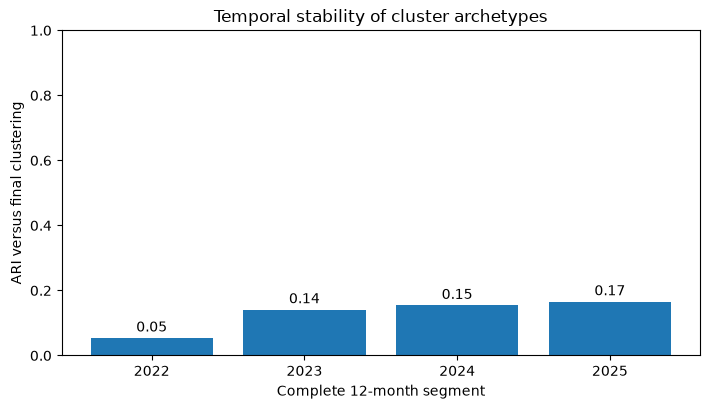

,year,start_date,end_date,n_days,ari_vs_final,mean_nearest_centroid_distance
0,2022,2022-01-01,2022-12-31,365,0.053723,10.842195
1,2023,2023-01-01,2023-12-31,365,0.140802,6.819705
2,2024,2024-01-01,2024-12-31,366,0.153982,10.156911
3,2025,2025-01-01,2025-12-31,365,0.165349,6.003833


In [4]:
def complete_calendar_years(index: pd.DatetimeIndex) -> list[int]:
    counts = pd.Series(1, index=index).groupby(index.year).sum()
    expected = {year: (pd.Timestamp(year=year, month=12, day=31) - pd.Timestamp(year=year, month=1, day=1)).days + 1 for year in counts.index}
    return [year for year, n in counts.items() if n == expected[year]]


def nearest_centroid_assignments(
    segment: pd.DataFrame,
    reference_labels: pd.Series,
) -> tuple[pd.Series, pd.DataFrame]:
    """Assign each term to the nearest final-cluster centroid in one segment."""
    segment = segment.interpolate(method="time", limit_direction="both")
    trajectories = segment.T
    cluster_ids = sorted(reference_labels.unique())
    centroids = pd.DataFrame(
        {
            cluster_id: trajectories.loc[reference_labels.index[reference_labels == cluster_id]].mean(axis=0)
            for cluster_id in cluster_ids
        }
    ).T

    distances = np.empty((len(trajectories), len(cluster_ids)), dtype=float)
    X_terms = trajectories.to_numpy(dtype=float)
    for j, cluster_id in enumerate(cluster_ids):
        centroid = centroids.loc[cluster_id].to_numpy(dtype=float)
        distances[:, j] = np.sqrt(np.nanmean((X_terms - centroid) ** 2, axis=1))

    nearest = np.argmin(distances, axis=1)
    assignments = pd.Series(
        np.asarray(cluster_ids)[nearest], index=trajectories.index, name="cluster"
    ).astype(int)
    distance_table = pd.DataFrame(distances, index=trajectories.index, columns=cluster_ids)
    return assignments, distance_table


available_years = complete_calendar_years(panel_norm.index)
# Four complete years are available in the supplied 2022-01-01 to 2026-05-31 panel.
selected_years = available_years[-4:]
if len(selected_years) < 4:
    raise ValueError("At least four complete calendar years are required.")

annual_rows = []
annual_assignments = []
for year in selected_years:
    segment = panel_norm.loc[str(year)]
    year_labels, year_distances = nearest_centroid_assignments(segment, labels_final)
    ari = pairwise_label_ari(year_labels, labels_final)

    annual_rows.append({
        "year": year,
        "start_date": segment.index.min().date().isoformat(),
        "end_date": segment.index.max().date().isoformat(),
        "n_days": len(segment),
        "ari_vs_final": ari,
        "mean_nearest_centroid_distance": float(year_distances.min(axis=1).mean()),
    })
    annual_assignments.append(
        year_labels.rename(f"cluster_{year}")
    )

annual_stability = pd.DataFrame(annual_rows)
annual_stability.to_csv(OUTPUT_DIR / "annual_segment_stability.csv", index=False)
pd.concat(annual_assignments, axis=1).to_csv(
    OUTPUT_DIR / "annual_segment_assignments.csv"
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(annual_stability["year"].astype(str), annual_stability["ari_vs_final"])
ax.set_ylim(0, 1)
ax.set_xlabel("Complete 12-month segment")
ax.set_ylabel("ARI versus final clustering")
ax.set_title("Temporal stability of cluster archetypes")
for i, value in enumerate(annual_stability["ari_vs_final"]):
    ax.text(i, value + 0.02, f"{value:.2f}", ha="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "annual_segment_stability.png", dpi=300)
plt.show()

annual_stability


## 4. Consensus clustering under term subsampling

Repeatedly sample 80% of terms, recluster them, and estimate how often each pair is assigned together. The consensus matrix measures pairwise reproducibility; the cluster summary contrasts within-cluster consensus with the strongest competing cluster.


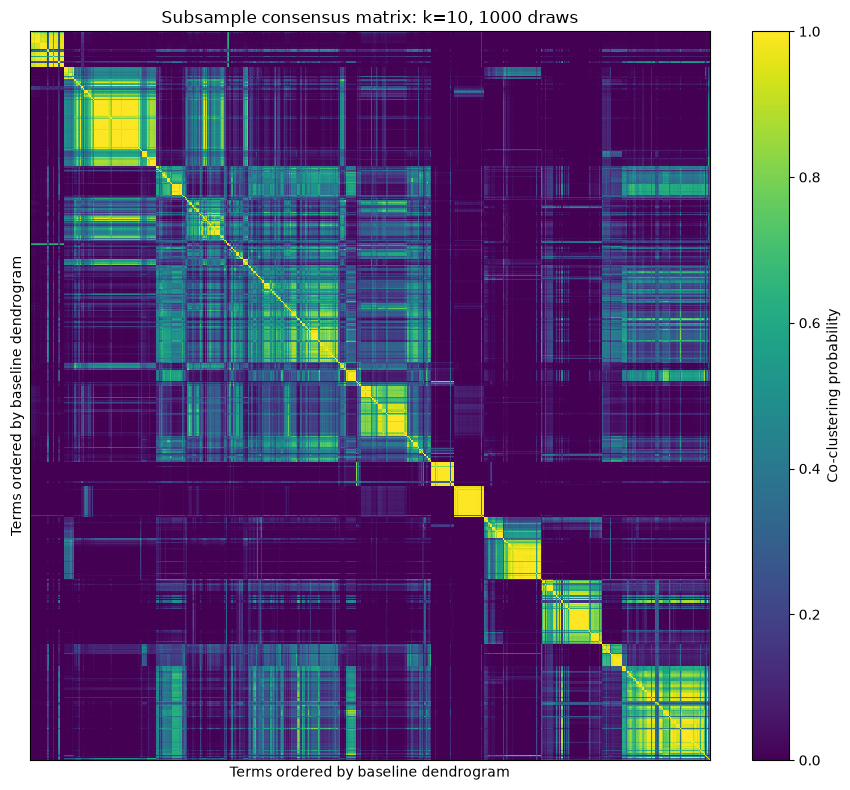

In [5]:
def calculate_consensus_matrix(
    full_distance: pd.DataFrame,
    k: int,
    method: str,
    n_subsamples: int,
    sample_fraction: float,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    validate_distance(full_distance)
    terms_local = full_distance.index
    n_terms = len(terms_local)
    n_take = min(n_terms - 1, max(k + 2, int(round(n_terms * sample_fraction))))
    rng = np.random.default_rng(seed)
    positions = pd.Series(np.arange(n_terms), index=terms_local)
    cooccurrence = np.zeros((n_terms, n_terms), dtype=np.int32)
    coclustering = np.zeros((n_terms, n_terms), dtype=np.int32)

    for _ in range(n_subsamples):
        sampled_terms = pd.Index(
            rng.choice(terms_local.to_numpy(), size=n_take, replace=False)
        )
        sampled_pos = positions.loc[sampled_terms].to_numpy(dtype=int)
        cooccurrence[np.ix_(sampled_pos, sampled_pos)] += 1

        sampled_labels = labels_from_precomputed_distance(
            full_distance.loc[sampled_terms, sampled_terms], k=k, method=method
        )
        for cluster_id in sampled_labels.unique():
            cluster_terms = sampled_labels.index[sampled_labels == cluster_id]
            cluster_pos = positions.loc[cluster_terms].to_numpy(dtype=int)
            coclustering[np.ix_(cluster_pos, cluster_pos)] += 1

    consensus = np.divide(
        coclustering,
        cooccurrence,
        out=np.full(coclustering.shape, np.nan, dtype=float),
        where=cooccurrence > 0,
    )
    np.fill_diagonal(consensus, 1.0)
    return (
        pd.DataFrame(consensus, index=terms_local, columns=terms_local),
        pd.DataFrame(coclustering, index=terms_local, columns=terms_local),
        pd.DataFrame(cooccurrence, index=terms_local, columns=terms_local),
    )


consensus_matrix, cocluster_counts, cooccurrence_counts = calculate_consensus_matrix(
    full_distance=mindist_tiebroken,
    k=FINAL_K,
    method=LINKAGE_METHOD,
    n_subsamples=CONSENSUS_SUBSAMPLES,
    sample_fraction=CONSENSUS_FRACTION,
    seed=RANDOM_STATE,
)
consensus_matrix.to_csv(OUTPUT_DIR / "consensus_matrix.csv")
cocluster_counts.to_csv(OUTPUT_DIR / "consensus_cocluster_counts.csv")
cooccurrence_counts.to_csv(OUTPUT_DIR / "consensus_cooccurrence_counts.csv")

baseline_tree = linkage(
    squareform(mindist_tiebroken.to_numpy(dtype=float), checks=False),
    method=LINKAGE_METHOD,
)
leaf_order = dendrogram(baseline_tree, no_plot=True)["leaves"]
ordered_terms = terms[leaf_order]
ordered_consensus = consensus_matrix.loc[ordered_terms, ordered_terms]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(ordered_consensus, vmin=0, vmax=1, aspect="auto", interpolation="nearest")
ax.set_title(
    f"Subsample consensus matrix: k={FINAL_K}, {CONSENSUS_SUBSAMPLES} draws"
)
ax.set_xlabel("Terms ordered by baseline dendrogram")
ax.set_ylabel("Terms ordered by baseline dendrogram")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, label="Co-clustering probability")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "consensus_matrix.png", dpi=300)
plt.show()


## 5. Cluster-level consensus summary

Summarize each final cluster’s internal reproducibility and separation from its nearest competitor. Low within-cluster consensus or a small consensus margin flags clusters that require interpretation or possible refinement.


In [6]:
def summarize_consensus_by_cluster(
    consensus_df: pd.DataFrame,
    baseline_labels: pd.Series,
) -> pd.DataFrame:
    rows = []
    cluster_ids = sorted(baseline_labels.unique())

    for cluster_id in cluster_ids:
        own_terms = baseline_labels.index[baseline_labels == cluster_id]
        own_matrix = consensus_df.loc[own_terms, own_terms].to_numpy(dtype=float)
        own_values = own_matrix[~np.eye(len(own_terms), dtype=bool)]
        own_values = own_values[np.isfinite(own_values)]

        between_means = {}
        for alternative_id in cluster_ids:
            if alternative_id == cluster_id:
                continue
            alternative_terms = baseline_labels.index[baseline_labels == alternative_id]
            values = consensus_df.loc[own_terms, alternative_terms].to_numpy(dtype=float)
            values = values[np.isfinite(values)]
            between_means[alternative_id] = float(values.mean()) if values.size else np.nan

        valid_between = {k: v for k, v in between_means.items() if pd.notna(v)}
        nearest_cluster = max(valid_between, key=valid_between.get) if valid_between else np.nan
        max_between = valid_between.get(nearest_cluster, np.nan)
        mean_within = float(own_values.mean()) if own_values.size else np.nan

        rows.append({
            "cluster": int(cluster_id),
            "n_terms": int(len(own_terms)),
            "mean_within_consensus": mean_within,
            "median_within_consensus": float(np.median(own_values)) if own_values.size else np.nan,
            "p10_within_consensus": float(np.quantile(own_values, 0.10)) if own_values.size else np.nan,
            "nearest_competing_cluster": nearest_cluster,
            "max_mean_between_consensus": max_between,
            "consensus_margin": mean_within - max_between if pd.notna(max_between) else np.nan,
            # MANUAL JUDGMENT: treat this flag as a review prompt, not a universal cutoff.
            "manual_review_flag": bool(
                (pd.notna(mean_within) and mean_within < 0.60)
                or (pd.notna(max_between) and mean_within - max_between < 0.25)
            ),
        })

    return pd.DataFrame(rows).sort_values(
        ["manual_review_flag", "mean_within_consensus"],
        ascending=[False, True],
    ).reset_index(drop=True)


consensus_cluster_summary = summarize_consensus_by_cluster(
    consensus_matrix, labels_final
)
consensus_cluster_summary.to_csv(
    OUTPUT_DIR / "consensus_cluster_summary.csv", index=False
)
consensus_cluster_summary


,cluster,n_terms,mean_within_consensus,median_within_consensus,p10_within_consensus,nearest_competing_cluster,max_mean_between_consensus,consensus_margin,manual_review_flag
0,3,227,0.389568,0.387597,0.119808,4,0.272585,0.116983,True
1,4,116,0.412874,0.330508,0.083048,3,0.272585,0.140289,True
2,7,73,0.622969,0.577102,0.215629,2,0.046078,0.576891,False
3,8,74,0.690710,0.723301,0.381329,10,0.132028,0.558682,False
4,10,109,0.694559,0.727341,0.357475,3,0.254754,0.439805,False
5,2,115,0.697222,0.680751,0.388430,3,0.153327,0.543895,False
6,9,26,0.745607,0.686212,0.433754,3,0.235561,0.510046,False
7,1,42,0.769520,0.946117,0.274725,3,0.048275,0.721244,False
8,5,28,0.886551,1.000000,0.339076,4,0.057486,0.829065,False
9,6,37,0.954472,0.995420,0.923089,4,0.041116,0.913356,False
